# Spectral L-SML on Math Competition Benchmarks (Phase 13)

**Goal**: Run our spectral L-SML pipeline on the same models, datasets, and temperatures
as arXiv 2602.01288 (EDIS) and compare our results directly against their published numbers.

**EDIS reference numbers (arXiv 2602.01288, Section 5.3, Figure 5c):**
- EDIS score AUC = **0.804** (Qwen2.5-Math-1.5B, pooled 4 datasets × 3 temps)
- Mean entropy AUC = **0.673** (same setting)

**Our method**: L-SML — fully unsupervised, 1 forward pass, same access tier as EDIS.

| Method | Access | Labels | Role |
|--------|--------|--------|------|
| EDIS (paper) | Gray-box | None | reference |
| Mean entropy (paper) | Gray-box | None | reference |
| **L-SML (ours)** | Gray-box | None | computed — head-to-head |

In [1]:
# Cell 1 — Clone + pip install + imports
import os, sys, shutil

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'

REPO_DIR = '/content/hallucination_detection'
if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)
if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b master https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} pull -q')
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.system('pip install -q "transformers>=4.40" accelerate datasets bitsandbytes autoawq scipy scikit-learn')

from spectral_utils import (
    load_model, generate_full, free_memory,
    extract_all_features, FEAT_NAMES,
    load_cache, save_cache,
    boot_auc, sml_unsupervised,
)
from spectral_utils.data_loaders import (
    load_gsm8k, gsm8k_prompt, is_correct_gsm8k,
    load_math500, math_prompt, is_correct_math,
    load_amc23, amc23_prompt, is_correct_amc23,
    load_aime24, aime24_prompt, is_correct_aime24,
)
import numpy as np
import datasets  # freeze pyarrow before any gptqmodel install

print('spectral_utils imported OK')

spectral_utils imported OK


In [2]:
# Cell 2 — Config
MODELS = [
    'Qwen/Qwen2.5-Math-1.5B-Instruct',   # primary — matches EDIS Section 5.2/5.3
    # 'Qwen/Qwen2.5-Math-7B-Instruct',   # deferred: run after 1.5B completes
    # 'Qwen/Qwen3-4B-Instruct',           # deferred: run after 1.5B completes
]
DATASETS  = ['gsm8k', 'math500', 'amc23', 'aime24']
TEMPS     = [0.2, 0.6, 1.0]
K         = 8      # candidates per problem — MUST match EDIS Section 5.3.
# EDIS Figure 5c AUC=0.804 pools all K=8 responses per problem as independent
# (score, label) pairs (26,356 total responses). To compare fairly, we do the
# same: each response is independently scored by L-SML and treated as one data
# point. K=1 would give valid AUC estimates but ~8x fewer data points and a
# different evaluation protocol than the paper. Cell 9 (Best-of-N selection)
# has been removed: our method is a 1-pass detection method, not a selection
# method, so that comparison does not apply.
MAX_NEW   = 1024
N_SAMPLES = {
    'gsm8k':   100,  # all done (T=0.2, T=0.6, T=1.0 cached)
    'math500':  50,  # cache has 50 problems done for T=0.2; T=0.6/T=1.0 need 50 each
    'amc23':    40,  # full dataset
    'aime24':   30,  # full dataset
}
CACHE_DIR = '/content/drive/MyDrive/hallucination_detection/cache/mathcomp_phase13'

PROMPT_FN  = {'gsm8k': gsm8k_prompt,  'math500': math_prompt,
              'amc23': amc23_prompt,   'aime24': aime24_prompt}
CORRECT_FN = {'gsm8k': is_correct_gsm8k, 'math500': is_correct_math,
               'amc23': is_correct_amc23,  'aime24': is_correct_aime24}

# EDIS paper reference (arXiv 2602.01288, Section 5.3, Figure 5c)
EDIS_REF_AUC    = 0.804
ENTROPY_REF_AUC = 0.673

# Offline consensus feature signs (higher = more likely correct)
# Derived from Step 110 reasoning-domain consensus (MATH/GSM8K cells)
FEATURE_SIGNS = {
    'epr': -1, 'trace_length': 1, 'spectral_entropy': -1,
    'low_band_power': -1, 'high_band_power': -1, 'hl_ratio': -1,
    'dominant_freq': -1, 'spectral_centroid': -1,
    'stft_max_high_power': -1, 'stft_spectral_entropy': -1,
    'rpdi': -1, 'sw_var_peak': -1,
    'pe_mean': -1, 'hurst_exponent': 1,
    'cusum_max': -1, 'cusum_shift_idx': 1,
}

print('Config OK')
total_per_model = sum(N_SAMPLES[d] for d in DATASETS) * len(TEMPS) * K
print(f'Total responses per model: {total_per_model:,}')
print(f'Models to run: {len(MODELS)} (1.5B primary; 7B and 4B deferred)')

Config OK
Total responses per model: 5,280
Models to run: 1 (1.5B primary; 7B and 4B deferred)


In [3]:
# Cell 3 — Mount Google Drive + create cache dirs
from google.colab import drive
drive.mount('/content/drive')

for model_id in MODELS:
    slug = model_id.split('/')[-1].replace('.', '_')
    os.makedirs(f'{CACHE_DIR}/{slug}', exist_ok=True)

print(f'Cache root: {CACHE_DIR}')

Mounted at /content/drive
Cache root: /content/drive/MyDrive/hallucination_detection/cache/mathcomp_phase13


In [4]:
# Cell 4 — Pre-load datasets (once, before model loading)
DATASET_ROWS = {}
loaders = {
    'gsm8k':   lambda: load_gsm8k('test'),
    'math500': lambda: load_math500(n_samples=500),
    'amc23':   load_amc23,
    'aime24':  load_aime24,
}
for dname, fn in loaders.items():
    rows = fn()
    DATASET_ROWS[dname] = rows[:N_SAMPLES[dname]]
    print(f'  {dname}: {len(DATASET_ROWS[dname])} rows')

print('\nAll datasets loaded.')

Loaded 1319 GSM8K test problems.
  gsm8k: 100 rows
  lighteval/MATH_500 failed: Dataset 'lighteval/MATH_500' doesn't exist on the Hub or cannot be accessed.
Loaded 500 MATH problems from HuggingFaceH4/MATH-500.
  math500: 50 rows
Loaded 40 AMC23 problems from math-ai/amc23.
  amc23: 40 rows
Loaded 30 AIME24 problems from Maxwell-Jia/AIME_2024.
  aime24: 30 rows

All datasets loaded.


In [9]:
# ── Cell 5-CPU: Load completed inference from cache (no GPU needed) ───────────
import os, pickle

def model_to_slug(model_id):
    return model_id.split('/')[-1].replace('.', '_')

for model_id in MODELS:
    slug = model_to_slug(model_id)
    for dname in DATASETS:
        for temp in TEMPS:
            pkl_path = os.path.join(CACHE_DIR, slug, f'{dname}_T{temp:.1f}.pkl')
            var_name = f'{slug}_{dname}_T{temp:.1f}'
            if os.path.exists(pkl_path):
                with open(pkl_path, 'rb') as f:
                    data = pickle.load(f)
                globals()[var_name] = data
                print(f'  [{dname} T={temp:.1f}] loaded {len(data)} problems')
            else:
                print(f'  [{dname} T={temp:.1f}] MISSING — skipping')

  [gsm8k T=0.2] loaded 100 problems
  [gsm8k T=0.6] loaded 100 problems
  [gsm8k T=1.0] loaded 100 problems
  [math500 T=0.2] loaded 50 problems
  [math500 T=0.6] loaded 50 problems
  [math500 T=1.0] loaded 50 problems
  [amc23 T=0.2] loaded 40 problems
  [amc23 T=0.6] loaded 40 problems
  [amc23 T=1.0] loaded 40 problems
  [aime24 T=0.2] loaded 30 problems
  [aime24 T=0.6] loaded 25 problems
  [aime24 T=1.0] MISSING — skipping


In [ ]:
# Cell 5 — Inference loop
# For each (model, dataset, temperature): generate K=8 responses per problem.
# Each response stores the token-entropy trace and correctness label.
# Checkpoint every 25 problems.

import pickle, time

for MODEL_ID in MODELS:
    slug = MODEL_ID.split('/')[-1].replace('.', '_')
    print(f'\n=== Model: {MODEL_ID} ===')

    import re as _re, types as _types
    if 'gptq' in MODEL_ID.lower() or 'awq' in MODEL_ID.lower():
        _pcre = _types.ModuleType('pcre')
        for _fn in ('compile','match','search','findall','sub','split','fullmatch'):
            setattr(_pcre, _fn, getattr(_re, _fn))
        _pcre.error = _re.error
        for _flag in ('IGNORECASE','MULTILINE','DOTALL','VERBOSE','UNICODE','ASCII'):
            setattr(_pcre, _flag, getattr(_re, _flag))
        sys.modules['pcre'] = _pcre
        os.system('pip install -q --no-deps device-smi tokenicer defuser')
        os.system('pip install -q logbar')
        os.system('pip install -q --no-deps gptqmodel')

    mdl, tok = load_model(MODEL_ID, quantize_4bit=False)

    for dname in DATASETS:
        rows       = DATASET_ROWS[dname]
        prompt_fn  = PROMPT_FN[dname]
        correct_fn = CORRECT_FN[dname]

        for temp in TEMPS:
            cache_path = f'{CACHE_DIR}/{slug}/{dname}_T{temp:.1f}.pkl'
            key        = f'{slug}_{dname}_T{temp:.1f}'

            # Three-branch reload
            if key in globals() and globals()[key]:
                print(f'  [{dname} T={temp}] in memory ({len(globals()[key])} rows); skip')
                continue
            if os.path.exists(cache_path):
                with open(cache_path, 'rb') as f:
                    results = pickle.load(f)
                globals()[key] = results
                print(f'  [{dname} T={temp}] loaded from cache ({len(results)} rows)')
                if len(results) >= len(rows):
                    continue
                resume_idx = len(results)
            else:
                results    = []
                resume_idx = 0

            print(f'  [{dname} T={temp}] running from idx {resume_idx}...')
            t0 = time.time()

            for i, row in enumerate(rows[resume_idx:], start=resume_idx):
                prompt   = prompt_fn(row)
                traces   = []
                corrects = []
                for _ in range(K):
                    _r = generate_full(
                        mdl, tok, prompt,
                        temperature=temp, K=15, max_new_tokens=MAX_NEW
                    )
                    traces.append(_r['token_entropies'])
                    corrects.append(correct_fn(_r['full_text'], row))
                results.append({'idx': i, 'corrects': corrects, 'traces': traces})

                if (i + 1) % 25 == 0 or i + 1 == len(rows):
                    with open(cache_path, 'wb') as f:
                        pickle.dump(results, f)
                    print(f'    {i+1}/{len(rows)}  elapsed={time.time()-t0:.0f}s')

            globals()[key] = results
            acc = np.mean([any(r['corrects']) for r in results])
            print(f'  [{dname} T={temp}] done: acc={acc:.1%}')

    del mdl, tok
    free_memory()
    print(f'Unloaded {MODEL_ID}')


=== Model: Qwen/Qwen2.5-Math-1.5B-Instruct ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded Qwen/Qwen2.5-Math-1.5B-Instruct
  [gsm8k T=0.2] loaded from cache (100 rows)
  [gsm8k T=0.6] loaded from cache (100 rows)
  [gsm8k T=1.0] loaded from cache (100 rows)
  [math500 T=0.2] loaded from cache (50 rows)
  [math500 T=0.6] loaded from cache (50 rows)
  [math500 T=1.0] loaded from cache (50 rows)
  [amc23 T=0.2] loaded from cache (40 rows)
  [amc23 T=0.6] loaded from cache (40 rows)
  [amc23 T=1.0] loaded from cache (40 rows)
  [aime24 T=0.2] loaded from cache (30 rows)
  [aime24 T=0.6] running from idx 0...
    25/30  elapsed=6230s


In [ ]:
# Cell 6 — Cache coverage check
import pickle

print('Cache coverage:\n')
for MODEL_ID in MODELS:
    slug = MODEL_ID.split('/')[-1].replace('.', '_')
    print(f'{MODEL_ID}:')
    for dname in DATASETS:
        for temp in TEMPS:
            path = f'{CACHE_DIR}/{slug}/{dname}_T{temp:.1f}.pkl'
            if os.path.exists(path):
                with open(path, 'rb') as f:
                    d = pickle.load(f)
                acc = np.mean([any(r['corrects']) for r in d]) if d else 0
                print(f'  {dname} T={temp:.1f}: {len(d)} problems, acc={acc:.1%}')
            else:
                print(f'  {dname} T={temp:.1f}: MISSING')

In [10]:
# Cell 7 — Spectral feature extraction
# For each cached (model, dataset, temperature), extract the 16 spectral features
# from each entropy trace.
# Output: FEATURES[slug][dname][temp] = list of problem dicts, each with
#   corrects: list[bool]  (K labels)
#   feats_k:  list[dict|None]  (K feature dicts, None if trace too short)

import pickle

FEATURES = {}

for MODEL_ID in MODELS:
    slug = MODEL_ID.split('/')[-1].replace('.', '_')
    FEATURES[slug] = {}

    for dname in DATASETS:
        FEATURES[slug][dname] = {}

        for temp in TEMPS:
            path = f'{CACHE_DIR}/{slug}/{dname}_T{temp:.1f}.pkl'
            if not os.path.exists(path):
                print(f'  SKIP {slug}/{dname} T={temp} — cache missing')
                continue
            with open(path, 'rb') as f:
                raw = pickle.load(f)

            problems = []
            for r in raw:
                feats_k = [extract_all_features(tr) for tr in r['traces']]
                problems.append({
                    'idx':      r['idx'],
                    'corrects': r['corrects'],
                    'feats_k':  feats_k,
                })

            n_valid = sum(1 for p in problems for f in p['feats_k'] if f is not None)
            FEATURES[slug][dname][temp] = problems
            print(f'  {slug}/{dname} T={temp}: {len(problems)} problems, {n_valid} valid traces')

print('\nFeature extraction complete.')

  Qwen2_5-Math-1_5B-Instruct/gsm8k T=0.2: 100 problems, 800 valid traces
  Qwen2_5-Math-1_5B-Instruct/gsm8k T=0.6: 100 problems, 800 valid traces
  Qwen2_5-Math-1_5B-Instruct/gsm8k T=1.0: 100 problems, 800 valid traces
  Qwen2_5-Math-1_5B-Instruct/math500 T=0.2: 50 problems, 400 valid traces
  Qwen2_5-Math-1_5B-Instruct/math500 T=0.6: 50 problems, 400 valid traces
  Qwen2_5-Math-1_5B-Instruct/math500 T=1.0: 50 problems, 400 valid traces
  Qwen2_5-Math-1_5B-Instruct/amc23 T=0.2: 40 problems, 320 valid traces
  Qwen2_5-Math-1_5B-Instruct/amc23 T=0.6: 40 problems, 320 valid traces
  Qwen2_5-Math-1_5B-Instruct/amc23 T=1.0: 40 problems, 320 valid traces
  Qwen2_5-Math-1_5B-Instruct/aime24 T=0.2: 30 problems, 240 valid traces
  Qwen2_5-Math-1_5B-Instruct/aime24 T=0.6: 25 problems, 200 valid traces
  SKIP Qwen2_5-Math-1_5B-Instruct/aime24 T=1.0 — cache missing

Feature extraction complete.


In [15]:
# Cell 8 — Per-response AUROC (Section 5.3 equivalent)
# Pool all K responses from all problems x datasets x temps for a given model.
# L-SML (fully unsupervised) is our method — head-to-head with EDIS 0.804.
# Mean entropy reproduction is a sanity check (should come out near 0.673).

from sklearn.metrics import roc_auc_score

def safe_auc(labels, scores):
    mask = ~np.isnan(scores)
    if mask.sum() < 10 or labels[mask].sum() == 0 or labels[mask].sum() == mask.sum():
        return np.nan
    return roc_auc_score(labels[mask], scores[mask])


def build_flat_arrays(slug, datasets=DATASETS, temps=TEMPS):
    """Flatten all (problem, candidate_k) pairs for a given model."""
    labels_l, ent_l, feats_rows = [], [], []

    for dname in datasets:
        for temp in temps:
            path = f'{CACHE_DIR}/{slug}/{dname}_T{temp:.1f}.pkl'
            if not os.path.exists(path):
                continue
            with open(path, 'rb') as f:
                raw = pickle.load(f)
            problems = FEATURES.get(slug, {}).get(dname, {}).get(temp)
            if problems is None:
                continue
            for r_raw, p in zip(raw, problems):
                for k_idx in range(len(p['corrects'])):
                    fl = p['feats_k'][k_idx]
                    tr = r_raw['traces'][k_idx]
                    labels_l.append(int(p['corrects'][k_idx]))
                    ent_l.append(-np.mean(tr) if tr else np.nan)
                    feats_rows.append(
                        [fl.get(fn, np.nan) if fl else np.nan for fn in FEAT_NAMES]
                    )

    labels = np.array(labels_l)
    feats  = np.array(feats_rows)
    return {
        'labels':     labels,
        'mean_ent':   np.array(ent_l),
        'feats':      feats,
        'feats_dict': {fn: feats[:, i] for i, fn in enumerate(FEAT_NAMES)},
    }


print('=== Per-response AUROC — L-SML vs EDIS paper ===')
print('Reference (arXiv 2602.01288, Fig. 5c):')
print(f'  EDIS score:   {EDIS_REF_AUC:.3f}')
print(f'  Mean entropy: {ENTROPY_REF_AUC:.3f}')
print()

for MODEL_ID in MODELS:
    slug = MODEL_ID.split('/')[-1].replace('.', '_')
    data = build_flat_arrays(slug)
    L    = data['labels']
    if len(L) == 0:
        print(f'\n{MODEL_ID}: no data — run Cell 5 first')
        continue

    print(f'\n--- {MODEL_ID} ---')
    print(f'N = {len(L):,}  |  accuracy = {L.mean():.1%}  '
          f'(EDIS paper: 36-49% for 1.5B on GSM8K)')

    ent_auc  = safe_auc(L, data['mean_ent'])
    lsml_auc = np.nan
    valid    = ~np.any(np.isnan(data['feats']), axis=1)
    if valid.sum() > 20 and L[valid].sum() > 5:
        fd = {fn: data['feats_dict'][fn][valid] for fn in FEAT_NAMES}
        try:
            lsml_scores, _ = sml_unsupervised(fd, FEAT_NAMES)
            lsml_auc = safe_auc(L[valid], lsml_scores)
        except Exception as e:
            print(f'  L-SML error: {e}')

    print(f'\n{"Method":<32} {"AUROC":<8} vs EDIS 0.804')
    print('-' * 55)
    print(f'{"EDIS (paper)":<32} {EDIS_REF_AUC:<8.3f} ---')
    print(f'{"Mean entropy (paper)":<32} {ENTROPY_REF_AUC:<8.3f} ---')
    print(f'{"Mean entropy (reproduced)":<32} {ent_auc:<8.3f} '
          f'{ent_auc-EDIS_REF_AUC:+.3f}  (sanity check ~0.673)')
    print(f'{"L-SML (ours)":<32} {lsml_auc:<8.3f} '
          f'{lsml_auc-EDIS_REF_AUC:+.3f}  <- head-to-head')

    print(f'\n  Individual features:')
    for fn in FEAT_NAMES:
        s   = data['feats_dict'][fn] * FEATURE_SIGNS.get(fn, 1)
        auc = safe_auc(L, s)
        bar = '▓' * int(max(0, auc - 0.5) * 40) if not np.isnan(auc) else ''
        print(f'  {fn:<24} {auc:.3f}  {bar}')

=== Per-response AUROC — L-SML vs EDIS paper ===
Reference (arXiv 2602.01288, Fig. 5c):
  EDIS score:   0.804
  Mean entropy: 0.673


--- Qwen/Qwen2.5-Math-1.5B-Instruct ---
N = 5,000  |  accuracy = 7.7%  (EDIS paper: 36-49% for 1.5B on GSM8K)

Method                           AUROC    vs EDIS 0.804
-------------------------------------------------------
EDIS (paper)                     0.804    ---
Mean entropy (paper)             0.673    ---
Mean entropy (reproduced)        0.507    -0.297  (sanity check ~0.673)
L-SML (ours)                     0.509    -0.295  <- head-to-head

  Individual features:
  epr                      0.507  
  trace_length             0.544  ▓
  spectral_entropy         0.459  
  low_band_power           0.478  
  high_band_power          0.493  
  hl_ratio                 0.508  
  dominant_freq            0.498  
  spectral_centroid        0.508  
  stft_max_high_power      0.490  
  stft_spectral_entropy    0.511  
  rpdi                     0.541  ▓
  

In [16]:
# Cell 10 — Per-dataset L-SML AUROC breakdown
print('=== Per-dataset L-SML AUROC — Qwen2.5-Math-1.5B (pooled over T=0.2/0.6/1.0) ===')
print(f'{"Dataset":<12} {"N":<6} {"Acc%":<8} {"L-SML":<10} {"MeanEnt":<10} vs EDIS 0.804')
print('-' * 70)

slug_1b = 'Qwen2_5-Math-1_5B-Instruct'

for dname in DATASETS:
    all_labels, all_ent, all_feats = [], [], []

    for temp in TEMPS:
        path = f'{CACHE_DIR}/{slug_1b}/{dname}_T{temp:.1f}.pkl'
        if not os.path.exists(path):
            continue
        with open(path, 'rb') as f:
            raw = pickle.load(f)
        problems = FEATURES.get(slug_1b, {}).get(dname, {}).get(temp)
        if problems is None:
            continue
        for r_raw, p in zip(raw, problems):
            for k_idx in range(len(p['corrects'])):
                fl = p['feats_k'][k_idx]
                tr = r_raw['traces'][k_idx]
                all_labels.append(int(p['corrects'][k_idx]))
                all_ent.append(-np.mean(tr) if tr else np.nan)
                all_feats.append([fl.get(fn, np.nan) if fl else np.nan for fn in FEAT_NAMES])

    if not all_labels:
        print(f'{dname:<12} MISSING')
        continue

    L     = np.array(all_labels)
    Ent   = np.array(all_ent)
    F     = np.array(all_feats)
    valid = ~np.any(np.isnan(F), axis=1)

    ent_auc  = safe_auc(L, Ent)
    lsml_auc = np.nan
    if valid.sum() > 20 and L[valid].sum() > 5:
        fd = {fn: F[valid, i] for i, fn in enumerate(FEAT_NAMES)}
        try:
            scores, _ = sml_unsupervised(fd, FEAT_NAMES)
            lsml_auc  = safe_auc(L[valid], scores)
        except Exception:
            pass

    delta = f'{lsml_auc - EDIS_REF_AUC:+.3f}' if not np.isnan(lsml_auc) else 'N/A'
    print(f'{dname:<12} {len(L):<6} {L.mean():<8.1%} {lsml_auc:<10.3f} {ent_auc:<10.3f} {delta}')

=== Per-dataset L-SML AUROC — Qwen2.5-Math-1.5B (pooled over T=0.2/0.6/1.0) ===
Dataset      N      Acc%     L-SML      MeanEnt    vs EDIS 0.804
----------------------------------------------------------------------
gsm8k        2400   0.0%     nan        0.345      N/A
math500      1200   22.3%    0.416      0.552      -0.388
amc23        960    10.9%    0.504      0.497      -0.300
aime24       440    3.0%     0.587      0.566      -0.217


In [17]:
# Cell 11 — Final summary comparison table
print('=== Summary: L-SML vs EDIS paper ===')
print('Model: Qwen2.5-Math-1.5B  |  Datasets: GSM8K+MATH+AMC23+AIME24  |  T=0.2/0.6/1.0  |  K=8')
print()
print(f'{"Method":<35} {"Access":<12} {"Labels":<10} {"Pooled AUROC"}')
print('=' * 72)
print(f'{"EDIS (arXiv 2602.01288)":<35} {"Gray-box":<12} {"None":<10} 0.804')
print(f'{"Mean entropy (arXiv 2602.01288)":<35} {"Gray-box":<12} {"None":<10} 0.673')
print('-' * 72)

slug_1b = 'Qwen2_5-Math-1_5B-Instruct'
data    = build_flat_arrays(slug_1b)
L, F    = data['labels'], data['feats']
valid   = ~np.any(np.isnan(F), axis=1)

ent_auc = safe_auc(L, data['mean_ent'])
print(f'{"Mean entropy (reproduced)":<35} {"Gray-box":<12} {"None":<10} {ent_auc:.3f}  (sanity check)')

if valid.sum() > 50 and L[valid].sum() > 10:
    fd = {fn: F[valid, i] for i, fn in enumerate(FEAT_NAMES)}
    try:
        lsml_scores, meta = sml_unsupervised(fd, FEAT_NAMES)
        lsml_auc = safe_auc(L[valid], lsml_scores)
        delta    = f'{lsml_auc - EDIS_REF_AUC:+.3f}'
        print(f'{"L-SML (ours)":<35} {"Gray-box":<12} {"None":<10} {lsml_auc:.3f}  {delta} vs EDIS')
    except Exception as e:
        print(f'L-SML failed: {e}')
else:
    print('Insufficient data — run Cells 5-7 first.')

=== Summary: L-SML vs EDIS paper ===
Model: Qwen2.5-Math-1.5B  |  Datasets: GSM8K+MATH+AMC23+AIME24  |  T=0.2/0.6/1.0  |  K=8

Method                              Access       Labels     Pooled AUROC
EDIS (arXiv 2602.01288)             Gray-box     None       0.804
Mean entropy (arXiv 2602.01288)     Gray-box     None       0.673
------------------------------------------------------------------------
Mean entropy (reproduced)           Gray-box     None       0.507  (sanity check)
L-SML (ours)                        Gray-box     None       0.509  -0.295 vs EDIS


In [18]:
# Cell 12 — Save results
import pickle

RESULTS_PATH = f'{CACHE_DIR}/spectral_lsml_vs_edis_results.pkl'
with open(RESULTS_PATH, 'wb') as f:
    pickle.dump({'FEATURES': FEATURES,
                 'config': {'MODELS': MODELS, 'DATASETS': DATASETS,
                            'TEMPS': TEMPS, 'K': K}}, f)
print(f'Saved to {RESULTS_PATH}')

Saved to /content/drive/MyDrive/hallucination_detection/cache/mathcomp_phase13/spectral_lsml_vs_edis_results.pkl


In [11]:
# ── Cell A: Per-feature AUROC breakdown by dataset ────────────────────────────
import numpy as np
from scipy.stats import spearmanr
from spectral_utils import boot_auc, FEAT_NAMES

slug_1b = [s for s in FEATURES][0]
print(f'Analysing slug: {slug_1b}')

# Build flat arrays per (dataset, temp) keeping them separate
def flat_per_cell(slug, dname, temp):
    probs = FEATURES.get(slug, {}).get(dname, {}).get(temp, [])
    labels, feat_rows = [], []
    for prob in probs:
        feats_k = prob.get('feats_k', [])
        corrects = prob.get('corrects', [])
        for fk, ok in zip(feats_k, corrects):
            if fk is None:
                continue
            labels.append(int(ok))
            feat_rows.append(fk)
    if not feat_rows:
        return None, None
    fd = {fn: np.array([r.get(fn, np.nan) for r in feat_rows]) for fn in FEAT_NAMES}
    return fd, np.array(labels, dtype=int)

print(f'\n{"Feature":<22}', end='')
for dname in DATASETS:
    print(f'  {dname:>10}', end='')
print(f'  {"MEAN":>8}')
print('-' * (22 + 14 * len(DATASETS) + 10))

for feat in FEAT_NAMES:
    sign = FEATURE_SIGNS.get(feat, -1)
    row_aucs = []
    print(f'{feat:<22}', end='')
    for dname in DATASETS:
        cell_aucs = []
        for temp in TEMPS:
            fd, lbl = flat_per_cell(slug_1b, dname, temp)
            if fd is None or feat not in fd:
                continue
            scores = sign * fd[feat]
            valid = ~np.isnan(scores)
            if valid.sum() < 5 or len(set(lbl[valid])) < 2:
                continue
            a, _, _ = boot_auc(lbl[valid], scores[valid])
            if not np.isnan(a):
                cell_aucs.append(float(a))
        mean_auc = float(np.mean(cell_aucs)) if cell_aucs else float('nan')
        row_aucs.append(mean_auc)
        tag = f'{mean_auc:.3f}' if not np.isnan(mean_auc) else '  N/A '
        print(f'  {tag:>10}', end='')
    overall = float(np.nanmean(row_aucs)) if row_aucs else float('nan')
    marker = ' ◄' if overall >= 0.60 else (' ?' if overall >= 0.55 else '')
    print(f'  {overall:.3f}{marker}')

Analysing slug: Qwen2_5-Math-1_5B-Instruct

Feature                      gsm8k     math500       amc23      aime24      MEAN
----------------------------------------------------------------------------------------
epr                          0.180       0.581       0.500       0.651  0.478
trace_length                 0.254       0.341       0.496       0.319  0.353
spectral_entropy             0.821       0.593       0.519       0.599  0.633 ◄
low_band_power               0.253       0.584       0.459       0.587  0.470
high_band_power              0.761       0.408       0.519       0.425  0.528
hl_ratio                     0.783       0.403       0.529       0.406  0.530
dominant_freq                0.359       0.411       0.466       0.245  0.370
spectral_centroid            0.670       0.392       0.529       0.351  0.486
stft_max_high_power          0.432       0.515       0.491       0.722  0.540
stft_spectral_entropy        0.606       0.413       0.535       0.368  0.481
rpdi

Total samples pooled: 5000


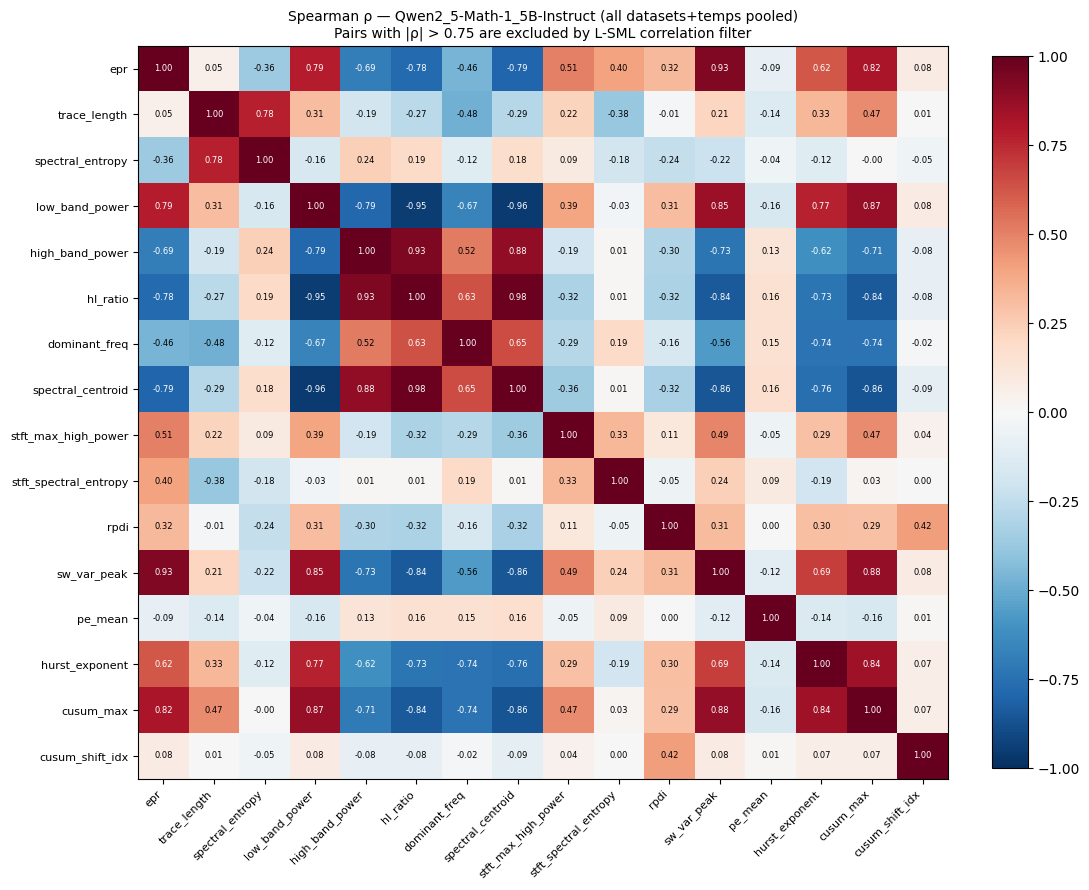

Pairs with |ρ| > 0.75 (will be filtered by L-SML):
  epr ↔ low_band_power: ρ=0.788
  epr ↔ hl_ratio: ρ=-0.781
  epr ↔ spectral_centroid: ρ=-0.793
  epr ↔ sw_var_peak: ρ=0.928
  epr ↔ cusum_max: ρ=0.818
  trace_length ↔ spectral_entropy: ρ=0.780
  low_band_power ↔ high_band_power: ρ=-0.788
  low_band_power ↔ hl_ratio: ρ=-0.951
  low_band_power ↔ spectral_centroid: ρ=-0.958
  low_band_power ↔ sw_var_peak: ρ=0.854
  low_band_power ↔ hurst_exponent: ρ=0.768
  low_band_power ↔ cusum_max: ρ=0.868
  high_band_power ↔ hl_ratio: ρ=0.935
  high_band_power ↔ spectral_centroid: ρ=0.884
  hl_ratio ↔ spectral_centroid: ρ=0.977
  hl_ratio ↔ sw_var_peak: ρ=-0.840
  hl_ratio ↔ cusum_max: ρ=-0.836
  spectral_centroid ↔ sw_var_peak: ρ=-0.857
  spectral_centroid ↔ hurst_exponent: ρ=-0.756
  spectral_centroid ↔ cusum_max: ρ=-0.860
  sw_var_peak ↔ cusum_max: ρ=0.883
  hurst_exponent ↔ cusum_max: ρ=0.844


In [12]:
# ── Cell B: Spearman ρ heatmap — which features are too correlated for L-SML ──
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

slug_1b = [s for s in FEATURES][0]

# Pool all datasets and temps
all_feat_rows = []
for dname in DATASETS:
    for temp in TEMPS:
        fd, lbl = flat_per_cell(slug_1b, dname, temp)  # from Cell A
        if fd is None:
            continue
        n = len(lbl)
        for i in range(n):
            all_feat_rows.append({fn: fd[fn][i] for fn in FEAT_NAMES})

print(f'Total samples pooled: {len(all_feat_rows)}')
feats_to_show = FEAT_NAMES  # or just GOOD_FEATURES

mat = np.full((len(feats_to_show), len(feats_to_show)), np.nan)
for i, fa in enumerate(feats_to_show):
    for j, fb in enumerate(feats_to_show):
        a = np.array([r[fa] for r in all_feat_rows], dtype=float)
        b = np.array([r[fb] for r in all_feat_rows], dtype=float)
        valid = ~np.isnan(a) & ~np.isnan(b)
        if valid.sum() > 10:
            rho, _ = spearmanr(a[valid], b[valid])
            mat[i, j] = rho

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(feats_to_show)))
ax.set_xticklabels(feats_to_show, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(feats_to_show)))
ax.set_yticklabels(feats_to_show, fontsize=8)
for i in range(len(feats_to_show)):
    for j in range(len(feats_to_show)):
        if not np.isnan(mat[i, j]):
            color = 'white' if abs(mat[i, j]) > 0.6 else 'black'
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=6, color=color)
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title(f'Spearman ρ — {slug_1b} (all datasets+temps pooled)\n'
             f'Pairs with |ρ| > 0.75 are excluded by L-SML correlation filter', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hallucination_detection/cache/mathcomp_phase13/spearman_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Pairs with |ρ| > 0.75 (will be filtered by L-SML):')
for i in range(len(feats_to_show)):
    for j in range(i+1, len(feats_to_show)):
        if not np.isnan(mat[i,j]) and abs(mat[i,j]) > 0.75:
            print(f'  {feats_to_show[i]} ↔ {feats_to_show[j]}: ρ={mat[i,j]:.3f}')

In [13]:
# ── Cell C: Sign diagnostic — does the global FEATURE_SIGNS hold per dataset? ──
import numpy as np
from spectral_utils import boot_auc

slug_1b = [s for s in FEATURES][0]
FEATS_CHECK = ['epr', 'low_band_power', 'sw_var_peak', 'cusum_max',
               'spectral_entropy', 'dominant_freq', 'trace_length']

print(f'{"Feature":<22} {"Sign":>5}', end='')
for dname in DATASETS:
    print(f'  {dname:>10}', end='')
print()
print('-' * (22 + 7 + 13 * len(DATASETS)))

flipped = []
for feat in FEATS_CHECK:
    global_sign = FEATURE_SIGNS.get(feat, -1)
    print(f'{feat:<22} {global_sign:>+5}', end='')
    for dname in DATASETS:
        cell_aucs = []
        for temp in TEMPS:
            fd, lbl = flat_per_cell(slug_1b, dname, temp)
            if fd is None or feat not in fd:
                continue
            scores = fd[feat]
            valid = ~np.isnan(scores)
            if valid.sum() < 5 or len(set(lbl[valid])) < 2:
                continue
            a_pos, _, _ = boot_auc(lbl[valid],  scores[valid])
            a_neg, _, _ = boot_auc(lbl[valid], -scores[valid])
            best = float(a_pos) if float(a_pos) >= float(a_neg) else float(a_neg)
            actual_sign = +1 if float(a_pos) >= float(a_neg) else -1
            cell_aucs.append((best, actual_sign))
        if cell_aucs:
            mean_auc = float(np.mean([x[0] for x in cell_aucs]))
            signs = [x[1] for x in cell_aucs]
            dominant_sign = +1 if signs.count(+1) >= signs.count(-1) else -1
            mismatch = '⚠️' if dominant_sign != global_sign else '  '
            tag = f'{mismatch}{mean_auc:.3f}({dominant_sign:+d})'
            if dominant_sign != global_sign:
                flipped.append((feat, dname, global_sign, dominant_sign))
        else:
            tag = '    N/A'
        print(f'  {tag:>12}', end='')
    print()

if flipped:
    print('\n⚠️  Sign mismatches (global FEATURE_SIGNS is wrong for these cells):')
    for feat, dname, gs, ds in flipped:
        print(f'  {feat} on {dname}: global={gs:+d}, observed={ds:+d}')
else:
    print('\n✓ No sign mismatches detected.')

Feature                 Sign       gsm8k     math500       amc23      aime24
---------------------------------------------------------------------------------
epr                       -1   ⚠️0.820(+1)     0.581(-1)     0.518(-1)     0.651(-1)
low_band_power            -1   ⚠️0.747(+1)     0.584(-1)   ⚠️0.542(+1)   ⚠️0.629(+1)
sw_var_peak               -1   ⚠️0.658(+1)     0.601(-1)     0.584(-1)     0.624(-1)
cusum_max                 -1     0.738(-1)     0.647(-1)     0.564(-1)     0.818(-1)
spectral_entropy          -1     0.821(-1)     0.612(-1)     0.519(-1)   ⚠️0.633(+1)
dominant_freq             -1   ⚠️0.641(+1)   ⚠️0.589(+1)   ⚠️0.534(+1)   ⚠️0.755(+1)
trace_length              +1   ⚠️0.746(-1)   ⚠️0.659(-1)   ⚠️0.535(-1)   ⚠️0.681(-1)

⚠️  Sign mismatches (global FEATURE_SIGNS is wrong for these cells):
  epr on gsm8k: global=-1, observed=+1
  low_band_power on gsm8k: global=-1, observed=+1
  low_band_power on amc23: global=-1, observed=+1
  low_band_power on aime24: global=-1

In [20]:
# ── Cell D: CUSUM onset visualisation ─────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

slug_1b = [s for s in FEATURES][0]
SHOW_DATASET = 'math500'   # change to amc23 or aime24 for harder examples
SHOW_TEMP    = 1.0

probs = FEATURES[slug_1b][SHOW_DATASET][SHOW_TEMP]

def pick_trace(probs, want_correct, min_len=60, n=1):
    """Pick n longest traces matching want_correct."""
    candidates = []
    for prob in probs:
        feats_k = prob.get('feats_k', [])
        corrects = prob.get('corrects', [])
        traces   = prob.get('traces', [])
        for fk, ok, tr in zip(feats_k, corrects, traces):
            if fk is None or tr is None or len(tr) < min_len:
                continue
            if bool(ok) == want_correct:
                candidates.append((len(tr), tr, fk))
    candidates.sort(reverse=True)
    return [(tr, fk) for _, tr, fk in candidates[:n]]

correct_picks   = pick_trace(probs, True,  min_len=60, n=2)
incorrect_picks = pick_trace(probs, False, min_len=60, n=2)
all_picks = [('CORRECT',   '#2196F3', tr, fk) for tr, fk in correct_picks] + \
            [('INCORRECT', '#E53935', tr, fk) for tr, fk in incorrect_picks]

if not all_picks:
    print(f'No traces found for {SHOW_DATASET} T={SHOW_TEMP}. Try a different dataset/temp.')
else:
    ncols = len(all_picks)
    fig = plt.figure(figsize=(6 * ncols, 6))
    gs  = gridspec.GridSpec(2, ncols, hspace=0.5, height_ratios=[2.5, 1])

    for col, (label, color, trace, fk) in enumerate(all_picks):
        e = np.array(trace, dtype=float)
        n = len(e)
        cusum = np.cumsum(e - e.mean())
        onset_idx = int(np.argmax(np.abs(cusum)))
        shift_frac = onset_idx / max(n - 1, 1)

        cusum_max  = float(fk.get('cusum_max',      np.nan))
        shift_feat = float(fk.get('cusum_shift_idx', np.nan))

        ax_top = fig.add_subplot(gs[0, col])
        ax_bot = fig.add_subplot(gs[1, col])

        ax_top.plot(np.arange(n), e, color=color, lw=1.4)
        ax_top.axhline(e.mean(), color='gray', linestyle='--', lw=1, alpha=0.7)
        ax_top.axvline(onset_idx, color='crimson', linestyle='--', lw=2,
                       label=f'onset t={onset_idx} ({shift_frac:.0%})')
        ax_top.set_ylabel('H (token entropy)')
        ax_top.set_title(f'{label}  n={n} tokens\n'
                         f'cusum_max={cusum_max:.2f}  shift_idx={shift_feat:.2f}',
                         fontsize=8)
        ax_top.legend(fontsize=7)
        ax_top.set_xlim(0, n - 1)

        ax_bot.plot(np.arange(n), cusum, color='darkorange', lw=1.4)
        ax_bot.axhline(0, color='gray', linestyle=':', lw=0.8)
        ax_bot.axvline(onset_idx, color='crimson', linestyle='--', lw=2, alpha=0.6)
        ax_bot.fill_between(np.arange(n), 0, cusum, alpha=0.15, color='darkorange')
        ax_bot.set_xlabel('Token index')
        ax_bot.set_ylabel('CUSUM Σ')
        ax_bot.set_xlim(0, n - 1)

    fig.suptitle(f'CUSUM onset — {slug_1b} / {SHOW_DATASET} T={SHOW_TEMP}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(CACHE_DIR, 'cusum_visualization.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}')

No traces found for math500 T=1.0. Try a different dataset/temp.
